#### Importing different packages

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

#### Loading Data

In [40]:
df = pd.read_csv('D:/AI-ML/mlproject/notebook/data/stud.csv')

In [41]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [42]:
X = df.drop('math_score', axis = 1)
X.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [43]:
y = df['math_score']
y.head()

0    72
1    69
2    90
3    47
4    76
Name: math_score, dtype: int64

In [44]:
# Check various category present in the different categorical column

print(f"Categories in gender column: {df['gender'].unique().tolist()}")
print(f"Categories in race_ethnicity :{df['race_ethnicity'].unique().tolist()}")
print(f"Categories in parental_level_of_education : {df['parental_level_of_education'].unique().tolist()}")
print(f"Categories in lunch : {df['lunch'].unique().tolist()}")
print(f"Categories in test_preparation_course : {df['test_preparation_course'].unique().tolist()}")

Categories in gender column: ['female', 'male']
Categories in race_ethnicity :['group B', 'group C', 'group A', 'group D', 'group E']
Categories in parental_level_of_education : ["bachelor's degree", 'some college', "master's degree", "associate's degree", 'high school', 'some high school']
Categories in lunch : ['standard', 'free/reduced']
Categories in test_preparation_course : ['none', 'completed']


In [45]:
number_features = X.select_dtypes(exclude = 'object').columns
category_feature = X.select_dtypes(include = 'object').columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transform = StandardScaler()
onehot_transform = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", onehot_transform, category_feature),
        ("StandardScaler", numeric_transform, number_features),

    ]
)

C:\Users\Dell\AppData\Local\Temp\ipykernel_15476\861759962.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  category_feature = X.select_dtypes(include = 'object').columns


In [46]:
X = preprocessor.fit_transform(X)

In [47]:
X.shape

(1000, 19)

#### Preparing X & Y Variable

In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print("X Train Shape : ", X_train.shape)
print("X Test Shape : ", X_test.shape)

X Train Shape :  (800, 19)
X Test Shape :  (200, 19)


#### Creating an evaluation function

In [49]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

#### Model Training

In [50]:
models = {
    "Linear Regression" : LinearRegression(),
    "Lasso" : Lasso(),
    "Ridge" : Ridge(),
    "K-Neighours" : KNeighborsRegressor(),
    "Decision Tree" : DecisionTreeRegressor(),
    "Random Forest" : RandomForestRegressor(),
    "XGBRegressor" : XGBRegressor(),
    "Catboost" : CatBoostRegressor(),
    "Adaboost" : AdaBoostRegressor()
}

model_list = []
r2_list = []

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred) 
    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    r2_list.append(model_test_r2)

    print("Model perfromance on training data")
    print("MAE :", model_train_mae)
    print("RMSE :", model_train_rmse)
    print("R Squared :", model_train_r2)

    print("----------------------------------")

    print("Model performance on testing data")
    print("MAE :", model_test_mae)
    print("RMSE :", model_test_rmse)
    print("R Squared :", model_test_r2)

    print('='*35)
    print('\n')


Linear Regression


Model perfromance on training data
MAE : 4.266711846071957
RMSE : 5.323050852720514
R Squared : 0.8743172040139593
----------------------------------
Model performance on testing data
MAE : 4.21476314247485
RMSE : 5.393993869732843
R Squared : 0.8804332983749565


Lasso
Model perfromance on training data
MAE : 5.206302661246528
RMSE : 6.593815587795568
R Squared : 0.8071462015863455
----------------------------------
Model performance on testing data
MAE : 5.157881810347764
RMSE : 6.519694535667422
R Squared : 0.8253197323627852


Ridge
Model perfromance on training data
MAE : 4.264987823725981
RMSE : 5.323324922741654
R Squared : 0.8743042615212909
----------------------------------
Model performance on testing data
MAE : 4.211100688014261
RMSE : 5.390387016935642
R Squared : 0.8805931485028737


K-Neighours
Model perfromance on training data
MAE : 4.5175
RMSE : 5.709062970400659
R Squared : 0.8554279731066252
----------------------------------
Model performance on testing data
MAE :

#### Model Result

In [51]:
pd.DataFrame(list(zip(model_list, r2_list)), columns = ['Model Name', 'R2_Score']).sort_values(by = ["R2_Score"], ascending = False)


,Model Name,R2_Score
2,Ridge,0.880593
0,Linear Regression,0.880433
5,Random Forest,0.851674
7,Catboost,0.851632
8,Adaboost,0.849071
6,XGBRegressor,0.827797
1,Lasso,0.825320
3,K-Neighours,0.783497
4,Decision Tree,0.728793


#### Linear Regression

In [53]:
linear_model = LinearRegression(fit_intercept = True)
linear_model = linear_model.fit(X_train, y_train)
y_pred = linear_model.predict(X_test)
score = r2_score(y_test, y_pred) * 100
print("Accuracy of this model :", score,"%")

Accuracy of this model : 88.04332983749565 %


#### Plotting y_test and y_pred

Text(0, 0.5, 'Predicted')

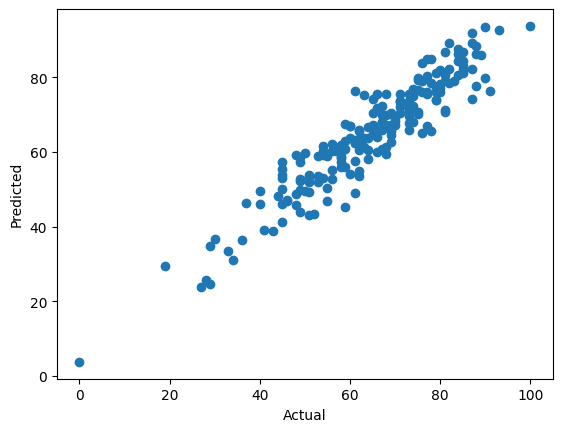

In [54]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")

<Axes: xlabel='math_score'>

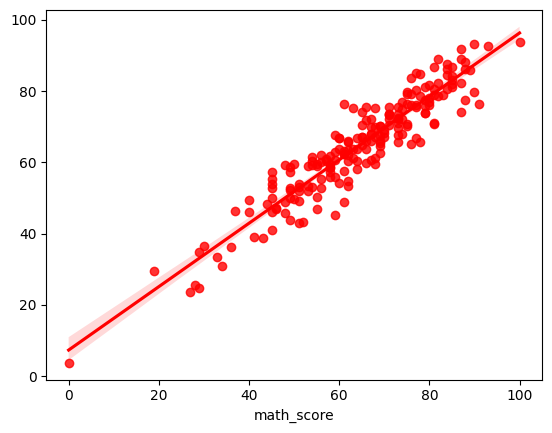

In [57]:
sns.regplot(x = y_test, y = y_pred, color = 'red')

#### Difference between actual and predicted values

In [59]:
pred_df = pd.DataFrame({'Actual Values' : y_test, 'Predicted Values' : y_pred, 'Difference' : y_test - y_pred})
pred_df

,Actual Values,Predicted Values,Difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
